#### Predicting Customer Purchase Behaviour

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
X = np.array([
    [19, 19000],
    [35, 20000],
    [26, 43000],
    [27, 57000],
    [46, 80000],
    [48, 29000],
    [50, 83000],
    [23, 48000],
    [32, 150000],
    [40, 65000]
])

y = np.array([
    0,0,0,0,1,
    1,1,0,1,1
])

In [30]:
# Normalize the features
mean = X.mean(axis=0)
std = X.std(axis=0)

X_scaled = (X-mean)/std

In [31]:
# Initialize
m,n = X.shape
weights = np.zeros(n)
bias = 0

learning_rate = 0.1
epochs = 3000

In [32]:
# Define the sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [33]:
# Logistic Regression Algorithm

for epoch in range(epochs):
    # Forward Pass
    z = np.dot(X_scaled,weights) + bias
    prediction = sigmoid(z)
    
    # Gradients
    dw = (1/m) * np.dot(X_scaled.T, (prediction-y))
    db = (1/m) * np.sum(prediction-y)
    
    # Update
    weights -= learning_rate*dw
    bias -= learning_rate*db

In [34]:
# New data prediction
new_customer = np.array([[30, 60000]])

new_customer_scaled = (
    new_customer - X_scaled.mean()
) / X_scaled.std()

probability = sigmoid(
    np.dot(new_customer_scaled, weights)
    + bias
)

print(
    "Purchase probability:",
    probability[0]
)

Purchase probability: 1.0


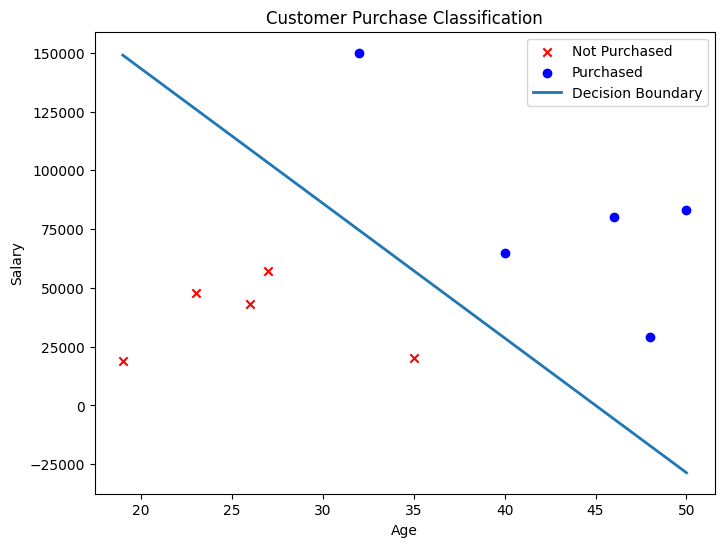

In [35]:
w1,w2 = weights
b = bias


# Plot data
plt.figure(figsize=(8,6))

plt.scatter(
    X[y==0,0],
    X[y==0,1],
    color='red',
    marker='x',
    label="Not Purchased"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    color='blue',
    marker='o',
    label="Purchased"
)

# Decision Boundary
age = np.linspace(
    X[:,0].min(),
    X[:,0].max(),
    100
)


salary = (
    mean[1]
    -
    (std[1]/w2)
    *
    (
        w1
        *
        (
            (age-mean[0])/std[0]
        )
        +
        bias
    )
)

plt.plot(age, salary, linewidth=2, label='Decision Boundary')

plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Customer Purchase Classification')
plt.legend()
plt.show()